# BranchOut Food (NASDAQ: BOF) — Probabilistic Scenario Valuation

**Why this model, not a 5-year DCF:** BOF is a sub-scale company whose future is a handful of
*discrete development paths*. Forecasting one precise income statement to 2030 would be false precision.
Instead we define the plausible paths, attach a probability to each, model the *consequence* for the
per-share value within each (as distributions, not points), and roll up via **Monte Carlo** into an
**expected value** *and* a **full probability distribution** of per-share outcomes.

The model is fully parametric — **edit the control panel in the next cell and re-run** to test any view.

Scenario tree (winning = *scaling works*) — deliberately **4 paths, no "super-bull" node**:

| # | Path | Definition |
|---|---|---|
| 1 | Failure | Going concern fails / dilution spiral → equity ≈ \$0 |
| 2 | Muddle | Survives sub-scale, chronic dilution, barely profitable |
| 3 | Scale & public | Scaling works; profitable growth co., stays public |
| 4 | Scale & acquired | Scaling works **and** a strategic buys it (PepsiCo/Hershey/Mondelez) |

The **\$200M "scale-further-then-sell" super-bull is the right tail of path 4**, not a separate scenario:
adding a discrete node would not change the expected value (the mean is linear) and would force an
invented probability. Instead, path 4 carries two correlations so the tail is *honest*:
**bigger exits take longer** (more discounting) and **take more dilution** (more shares).
`P(acquired) = P(scaling works) × P(sell | scaled)`; dilution risk = operational-scaling risk.

## 1. Setup & Control Panel

All assumptions live here. Triangular distributions are `(min, mode, max)`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

N_SIMS   = 200_000      # Monte Carlo draws
DISCOUNT = 0.12         # cost of equity (survival risk is in the probabilities, not the rate)

# ---- Current state (anchor, mid-2026) -------------------------------------
PRICE_NOW   = 4.28
SHARES_NOW  = 15.32     # million, basic

# ---- Path probabilities (must sum to 1.0) ---------------------------------
#   user priors 10/30/15/45 ; analyst counter 13/30/24/33 ; base = ~midpoint
P = {
    'failure'       : 0.12,
    'muddle'        : 0.30,
    'scale_public'  : 0.26,
    'scale_acquired': 0.32,
}
assert abs(sum(P.values()) - 1.0) < 1e-9, "probabilities must sum to 1"

# ---- Exit revenue ($M), triangular (min, mode, max) -----------------------
#   acquired tail reaches ~$220M to carry the "scale-further-then-sell" super-bull
REV = {
    'muddle'        : (22,  27,  32),
    'scale_public'  : (55,  85,  160),
    'scale_acquired': (75, 115,  220),
}
# ---- Exit valuation multiple (EV / Revenue), triangular -------------------
MULT = {
    'muddle'        : (1.0, 1.8, 2.5),   # weak small-cap
    'scale_public'  : (2.0, 2.8, 3.5),   # profitable public grower, no control premium
    'scale_acquired': (3.5, 4.0, 5.0),   # BFY-snack M&A cluster (3.6-4.4x); high-growth tail to 5.0x
}

# ---- DILUTION correlated with exit revenue (scaling paths) ----------------
#   shares = base + slope*(rev - ref) + noise   -> more capacity => more capital => more shares
DIL = {'ref_rev': 60, 'base_shares': 20.0, 'slope': 0.075, 'noise': 1.2}
#   e.g. @ $115M rev -> ~24M shares ; @ $200M -> ~30.5M shares
MUDDLE_SHARES = (28, 30, 40)             # muddle dilutes brutally (low prices)

# ---- Net debt at exit ($M): mild rise with revenue (scaling), flat (muddle)
NDV          = {'base': 9.0, 'slope': 0.04, 'ref_rev': 90}   # @ $200M -> ~$13.4M
NETDEBT_MUD  = 8.0

# ---- TIME to exit (years) -------------------------------------------------
#   acquired: correlated with revenue (bigger exit => longer): @75->4, @115->~5, @220->~7.5
TCORR        = {'ref_rev': 75, 'base_years': 4.0, 'slope': 0.0241, 'noise': 0.7}
YEARS_PUBLIC = (4, 5, 6)
YEARS_MUDDLE = (4, 5, 6)

# ---- Failure residual equity value per share (triangular) -----------------
FAIL_VPS = (0.0, 0.10, 0.50)

print("Control panel loaded.")
print(f"  Sims {N_SIMS:,} | Discount {DISCOUNT:.0%} | Price ${PRICE_NOW:.2f} | Shares now {SHARES_NOW:.2f}M")
print(f"  P(scaling works) = {P['scale_public']+P['scale_acquired']:.0%}  "
      f"[public {P['scale_public']:.0%} + acquired {P['scale_acquired']:.0%}]  |  "
      f"muddle {P['muddle']:.0%} | failure {P['failure']:.0%}")
print(f"  Acquired revenue tail reaches ${REV['scale_acquired'][2]:.0f}M (super-bull lives here)")

Control panel loaded.
  Sims 200,000 | Discount 12% | Price $4.28 | Shares now 15.32M
  P(scaling works) = 58%  [public 26% + acquired 32%]  |  muddle 30% | failure 12%
  Acquired revenue tail reaches $220M (super-bull lives here)


## 2. Monte Carlo Engine

Each draw picks a path by probability, then within the path:
`EV = revenue × multiple → equity = EV − net debt → per-share → discount to today`.

**Correlations in the scaling paths** (the new physics): exit **shares rise with revenue**
(more capacity ⇒ more capital ⇒ more dilution), and for the **acquired** path **time-to-exit rises
with revenue** (a \$200M exit lands ~7–8 yr out, not 5). This is what keeps the super-bull tail honest
instead of rewarding big revenue with no cost.

In [2]:
def tri(p, k): return np.random.triangular(p[0], p[1], p[2], k)

def run_mc(probs=P, rev=REV, mult=MULT, dil=None, dil_base=None, muddle_shares=MUDDLE_SHARES,
           ndv=NDV, netdebt_mud=NETDEBT_MUD, tcorr=TCORR, years_public=YEARS_PUBLIC,
           years_muddle=YEARS_MUDDLE, fail_vps=FAIL_VPS, discount=DISCOUNT, n=N_SIMS, seed=42):
    # Returns DataFrame: path label, present value per share, and exit (undiscounted) price.
    dil = dict(DIL) if dil is None else dil
    if dil_base is not None: dil = {**dil, 'base_shares': dil_base}
    rng = np.random.default_rng(seed)
    names = list(probs.keys())
    paths = rng.choice(len(names), size=n, p=np.array([probs[k] for k in names]))
    pv = np.empty(n); exitp = np.full(n, np.nan)

    for i, name in enumerate(names):
        mask = paths == i; k = int(mask.sum())
        if k == 0: continue
        if name == 'failure':
            pv[mask] = tri(fail_vps, k); continue
        if name == 'muddle':
            ev  = tri(rev['muddle'], k) * tri(mult['muddle'], k)
            sh  = tri(muddle_shares, k); yrs = tri(years_muddle, k)
            ep  = np.maximum(ev - netdebt_mud, 0) / sh
            exitp[mask] = ep; pv[mask] = ep / (1 + discount) ** yrs; continue
        # ---- scaling paths: correlated drivers ----
        r   = tri(rev[name], k); m = tri(mult[name], k)
        sh  = np.clip(dil['base_shares'] + dil['slope'] * (r - dil['ref_rev'])
                      + np.random.normal(0, dil['noise'], k), 17, None)        # dilution ~ revenue
        nd  = np.maximum(ndv['base'] + ndv['slope'] * (r - ndv['ref_rev']), 0)  # net debt ~ revenue
        if name == 'scale_acquired':
            yrs = np.clip(tcorr['base_years'] + tcorr['slope'] * (r - tcorr['ref_rev'])
                          + np.random.normal(0, tcorr['noise'], k), 2.5, 9)     # time ~ revenue
        else:
            yrs = tri(years_public, k)
        ep  = np.maximum(r * m - nd, 0) / sh
        exitp[mask] = ep; pv[mask] = ep / (1 + discount) ** yrs

    return pd.DataFrame({'path': [names[p] for p in paths], 'pv': pv, 'exit_price': exitp})

sim = run_mc()
print(f"Ran {len(sim):,} simulations. Mean implied exit shares (acquired) "
      f"≈ {(DIL['base_shares']+DIL['slope']*(115-DIL['ref_rev'])):.1f}M at $115M revenue.")
sim.head()

Ran 200,000 simulations. Mean implied exit shares (acquired) ≈ 24.1M at $115M revenue.


,path,pv,exit_price
0,scale_acquired,14.68,25.66
1,scale_public,6.45,11.28
2,scale_acquired,7.94,13.48
3,scale_acquired,14.24,27.25
4,failure,0.15,NaN


## 3. Headline Result — Expected Value & Distribution

In [3]:
pv = sim['pv'].values
exp_val = pv.mean(); median = np.median(pv); upside = exp_val / PRICE_NOW - 1
pctiles = {p: np.percentile(pv, p) for p in [5, 10, 25, 50, 75, 90, 95]}

print("="*60)
print(f"  Current price ...................... ${PRICE_NOW:>7.2f}")
print(f"  Probability-weighted EXPECTED value  ${exp_val:>7.2f}   ({upside:+.0%} vs price)")
print(f"  Median outcome ..................... ${median:>7.2f}")
print(f"  Expected return multiple ........... {exp_val/PRICE_NOW:>7.2f}x")
print("-"*60); print("  Percentiles of per-share PV:")
for p, v in pctiles.items(): print(f"    P{p:<2} .......... ${v:>7.2f}")
print("-"*60)
P_total_loss = (pv < 0.50).mean(); P_loss = (pv < PRICE_NOW).mean()
P_2x = (pv >= 2*PRICE_NOW).mean(); P_3x = (pv >= 3*PRICE_NOW).mean(); P_5x = (pv >= 5*PRICE_NOW).mean()
print("  Outcome probabilities (PV vs today's price):")
print(f"    Near-total loss (<$0.50) .. {P_total_loss:>5.1%}")
print(f"    Below today's price ....... {P_loss:>5.1%}")
print(f"    >= 2x ..................... {P_2x:>5.1%}")
print(f"    >= 3x ..................... {P_3x:>5.1%}")
print(f"    >= 5x ..................... {P_5x:>5.1%}")

  Current price ...................... $   4.28
  Probability-weighted EXPECTED value  $   5.61   (+31% vs price)
  Median outcome ..................... $   5.79
  Expected return multiple ...........    1.31x
------------------------------------------------------------
  Percentiles of per-share PV:
    P5  .......... $   0.16
    P10 .......... $   0.32
    P25 .......... $   0.66
    P50 .......... $   5.79
    P75 .......... $  10.28
    P90 .......... $  12.16
    P95 .......... $  13.04
------------------------------------------------------------
  Outcome probabilities (PV vs today's price):
    Near-total loss (<$0.50) .. 16.0%
    Below today's price ....... 42.7%
    >= 2x ..................... 33.5%
    >= 3x .....................  5.9%
    >= 5x .....................  0.0%


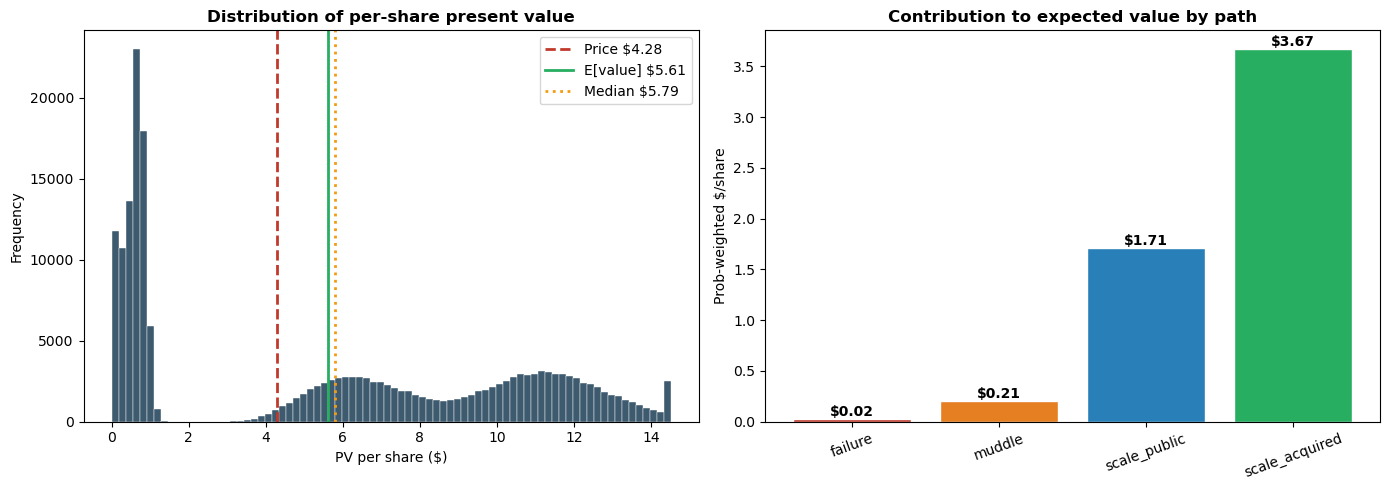

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
clip = np.percentile(pv, 99)
ax[0].hist(np.clip(pv, 0, clip), bins=80, color='#3d5a6e', edgecolor='white', linewidth=0.3)
ax[0].axvline(PRICE_NOW, color='#c0392b', lw=2, ls='--', label=f'Price ${PRICE_NOW:.2f}')
ax[0].axvline(exp_val, color='#27ae60', lw=2, label=f'E[value] ${exp_val:.2f}')
ax[0].axvline(median, color='#f39c12', lw=2, ls=':', label=f'Median ${median:.2f}')
ax[0].set_title('Distribution of per-share present value', fontweight='bold')
ax[0].set_xlabel('PV per share ($)'); ax[0].set_ylabel('Frequency'); ax[0].legend()

order = ['failure', 'muddle', 'scale_public', 'scale_acquired']
contrib = sim.groupby('path')['pv'].agg(['mean', 'count'])
contrib['prob'] = contrib['count'] / len(sim)
contrib['contribution'] = contrib['mean'] * contrib['prob']
contrib = contrib.loc[order]
colors = ['#c0392b', '#e67e22', '#2980b9', '#27ae60']
ax[1].bar(contrib.index, contrib['contribution'], color=colors, edgecolor='white')
ax[1].set_title('Contribution to expected value by path', fontweight='bold')
ax[1].set_ylabel('Prob-weighted $/share'); ax[1].tick_params(axis='x', rotation=20)
for x, v in zip(range(len(contrib)), contrib['contribution']):
    ax[1].text(x, v, f'${v:.2f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Per-Path Breakdown

In [5]:
tbl = sim.groupby('path')['pv'].agg(
    prob=lambda s: len(s)/len(sim), mean_value='mean', median_value='median',
    p10=lambda s: s.quantile(.10), p90=lambda s: s.quantile(.90))
tbl['contribution'] = tbl['prob'] * tbl['mean_value']; tbl = tbl.loc[order]
tbl.loc['— BLENDED —'] = [1.0, exp_val, median, np.percentile(pv,10),
                          np.percentile(pv,90), tbl['contribution'].sum()]
disp = tbl.copy(); disp['prob'] = (disp['prob']*100).round(1).astype(str)+'%'
for c in ['mean_value','median_value','p10','p90','contribution']:
    disp[c] = '$'+disp[c].round(2).astype(str)
disp

,prob,mean_value,median_value,p10,p90,contribution
path,,,,,,
failure,12.0%,$0.2,$0.18,$0.07,$0.36,$0.02
muddle,30.0%,$0.69,$0.69,$0.47,$0.92,$0.21
scale_public,26.1%,$6.55,$6.45,$4.88,$8.35,$1.71
scale_acquired,32.0%,$11.49,$11.4,$9.59,$13.5,$3.67
— BLENDED —,100.0%,$5.61,$5.79,$0.32,$12.16,$5.61


## 5. Super-Bull Readout — the \$200M tail of the acquired path

The "scale further to ~\$200M, then sell" outcome is **not a separate scenario** — it's the upper tail
of path 4. Below: the acquired-path distribution (so you can *see* the tail), plus the deterministic
\$200M case worked through with its honest time-and-dilution drag.

In [6]:
acq = sim[sim.path=='scale_acquired']
print("Acquired-path distribution (conditional on the path happening):")
for p in [50, 75, 90, 95, 99]:
    print(f"   P{p:<2}: exit ${np.percentile(acq.exit_price,p):>6.2f}  -> PV today ${np.percentile(acq.pv,p):>6.2f}")
print(f"   P(acquired exit price > $20) = {(acq.exit_price>20).mean():.0%} | > $30 = {(acq.exit_price>30).mean():.0%}")
print()
# Deterministic $200M super-bull, fully costed
def costed(rev_exit, mult_exit):
    sh  = DIL['base_shares'] + DIL['slope']*(rev_exit-DIL['ref_rev'])
    nd  = NDV['base'] + NDV['slope']*(rev_exit-NDV['ref_rev'])
    yrs = TCORR['base_years'] + TCORR['slope']*(rev_exit-TCORR['ref_rev'])
    ev  = rev_exit*mult_exit; eq = ev-nd; exitp = eq/sh; pvv = exitp/(1+DISCOUNT)**yrs
    return sh, nd, yrs, ev, exitp, pvv
print("Deterministic 'scale-further-then-sell' cases (mode path):")
print(f"{'Revenue':>9}{'Mult':>6}{'Shares':>8}{'NetDebt':>9}{'Years':>7}{'EV $M':>8}{'Exit $':>9}{'PV $':>8}{'x price':>9}")
for r_, m_ in [(115,4.0),(150,4.25),(200,4.25),(220,4.5)]:
    sh,nd,yr,ev,exq,pvv = costed(r_,m_)
    print(f"{r_:>9.0f}{m_:>6.2f}{sh:>8.1f}{nd:>9.1f}{yr:>7.1f}{ev:>8.0f}{exq:>9.2f}{pvv:>8.2f}{pvv/PRICE_NOW:>8.1f}x")

Acquired-path distribution (conditional on the path happening):
   P50: exit $ 21.29  -> PV today $ 11.40
   P75: exit $ 23.88  -> PV today $ 12.47
   P90: exit $ 26.20  -> PV today $ 13.50
   P95: exit $ 27.57  -> PV today $ 14.12
   P99: exit $ 30.04  -> PV today $ 15.37
   P(acquired exit price > $20) = 64% | > $30 = 1%

Deterministic 'scale-further-then-sell' cases (mode path):
  Revenue  Mult  Shares  NetDebt  Years   EV $M   Exit $    PV $  x price
      115  4.00    24.1     10.0    5.0     460    18.65   10.63     2.5x
      150  4.25    26.8     11.4    5.8     638    23.41   12.12     2.8x
      200  4.25    30.5     13.4    7.0     850    27.43   12.39     2.9x
      220  4.50    32.0     14.2    7.5     990    30.49   13.04     3.0x


## 6. Dilution Sensitivity Table  ⬅ *requested*

Vary the **dilution intercept** (`base_shares`) — i.e. how share-heavy the scaling journey is.
Shown as the implied diluted share count at the ~\$115M revenue mode, with the resulting blended
expected value, upside, and acquired-path value. Second axis: the acquisition EV/Revenue multiple.

In [7]:
dil_bases = [16, 18, 20, 23, 26]      # intercept; implied shares @ $115M = base + 0.075*55 = base+4.1
rows = []
for b in dil_bases:
    s = run_mc(dil_base=b, seed=7); pvd = s['pv'].values
    acqv = s.loc[s.path=='scale_acquired','pv'].values
    sh115 = b + DIL['slope']*(115-DIL['ref_rev'])
    rows.append({'Shares @ $115M (M)': round(sh115,1),
                 'Dilution vs today': f"{sh115/SHARES_NOW-1:+.0%}",
                 'Blended E[value]': pvd.mean(),
                 'Upside vs $4.28': f"{pvd.mean()/PRICE_NOW-1:+.0%}",
                 'Acquired-path E[value]': acqv.mean(),
                 'P(>=2x)': f"{(pvd>=2*PRICE_NOW).mean():.0%}"})
dil1d = pd.DataFrame(rows)
for c in ['Blended E[value]','Acquired-path E[value]']:
    dil1d[c] = '$'+dil1d[c].round(2).astype(str)
print("Dilution sensitivity — blended expected value & upside:")
dil1d

Dilution sensitivity — blended expected value & upside:


,Shares @ $115M (M),Dilution vs today,Blended E[value],Upside vs $4.28,Acquired-path E[value],P(>=2x)
0,20.10,+31%,$6.64,+55%,$13.61,40%
1,22.10,+44%,$6.09,+42%,$12.46,36%
2,24.10,+57%,$5.62,+31%,$11.48,34%
3,27.10,+77%,$5.04,+18%,$10.28,29%
4,30.10,+97%,$4.57,+7%,$9.31,23%


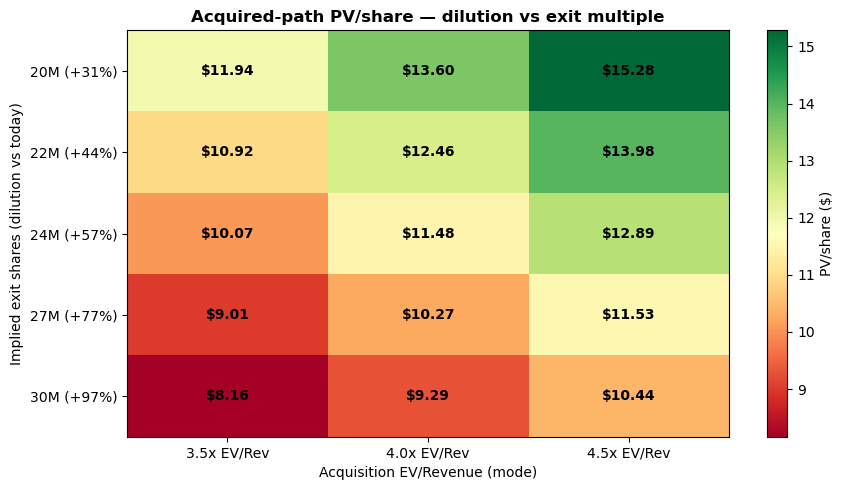

,3.5x,4.0x,4.5x
Exit shares (dilution),,,
20M (+31%),11.94,13.60,15.28
22M (+44%),10.92,12.46,13.98
24M (+57%),10.07,11.48,12.89
27M (+77%),9.01,10.27,11.53
30M (+97%),8.16,9.29,10.44


In [8]:
mult_modes = [3.5, 4.0, 4.5]
grid = np.zeros((len(dil_bases), len(mult_modes)))
for r_, b in enumerate(dil_bases):
    for c_, m in enumerate(mult_modes):
        mu = dict(MULT); mu['scale_acquired'] = (m-0.5, m, m+1.0)
        s = run_mc(dil_base=b, mult=mu, seed=11)
        grid[r_, c_] = s.loc[s.path=='scale_acquired','pv'].mean()
idx = [f"{b+DIL['slope']*(115-DIL['ref_rev']):.0f}M ({(b+DIL['slope']*55)/SHARES_NOW-1:+.0%})" for b in dil_bases]
grid2d = pd.DataFrame(grid, index=idx, columns=[f"{m:.1f}x" for m in mult_modes])
grid2d.index.name = 'Exit shares (dilution)'

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(grid2d.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(mult_modes))); ax.set_xticklabels([f"{m:.1f}x EV/Rev" for m in mult_modes])
ax.set_yticks(range(len(dil_bases))); ax.set_yticklabels(grid2d.index)
ax.set_title('Acquired-path PV/share — dilution vs exit multiple', fontweight='bold')
ax.set_xlabel('Acquisition EV/Revenue (mode)'); ax.set_ylabel('Implied exit shares (dilution vs today)')
for r_ in range(len(dil_bases)):
    for c_ in range(len(mult_modes)):
        ax.text(c_, r_, f'${grid2d.values[r_,c_]:.2f}', ha='center', va='center', fontweight='bold')
plt.colorbar(im, label='PV/share ($)'); plt.tight_layout(); plt.show()
grid2d.round(2)

## 7. Other Sensitivities — Probability of Scaling & Discount Rate

In [9]:
scaling_probs = [0.40, 0.50, 0.58, 0.66, 0.75]
acq_share = P['scale_acquired'] / (P['scale_public'] + P['scale_acquired'])
rows = []
for sp in scaling_probs:
    pp = {'failure': P['failure'], 'muddle': 1 - P['failure'] - sp,
          'scale_acquired': sp*acq_share, 'scale_public': sp*(1-acq_share)}
    v = run_mc(probs=pp, seed=5)['pv'].values
    rows.append({'P(scaling works)': f"{sp:.0%}", 'P(muddle)': f"{pp['muddle']:.0%}",
                 'E[value]': f"${v.mean():.2f}", 'Upside': f"{v.mean()/PRICE_NOW-1:+.0%}",
                 'P(>=2x)': f"{(v>=2*PRICE_NOW).mean():.0%}", 'P(loss)': f"{(v<PRICE_NOW).mean():.0%}"})
print("Sensitivity to P(scaling works):")
print(pd.DataFrame(rows).to_string(index=False))
print("\nSensitivity to discount rate:")
rows = [{'Discount': f"{dr:.1%}", 'E[value]': f"${run_mc(discount=dr, seed=3)['pv'].mean():.2f}",
         'Upside': f"{run_mc(discount=dr, seed=3)['pv'].mean()/PRICE_NOW-1:+.0%}"}
        for dr in [0.10, 0.12, 0.15, 0.175, 0.20]]
print(pd.DataFrame(rows).to_string(index=False))

Sensitivity to P(scaling works):
P(scaling works) P(muddle) E[value] Upside P(>=2x) P(loss)
             40%       48%    $4.07    -5%     23%     61%
             50%       38%    $4.92   +15%     29%     51%
             58%       30%    $5.60   +31%     33%     43%
             66%       22%    $6.30   +47%     38%     35%
             75%       13%    $7.06   +65%     43%     26%

Sensitivity to discount rate:
Discount E[value] Upside
   10.0%    $6.18   +44%
   12.0%    $5.62   +31%
   15.0%    $4.89   +14%
   17.5%    $4.36    +2%
   20.0%    $3.91    -9%


## 8. Summary

The model returns an **expected value** and a **full distribution**: the central estimate vs the $4.28 price,
*and* the shape of the bet (fat left tail from failure/muddle, fat right tail from a strategic exit).
Re-run with your own probabilities/assumptions in the control panel to make it yours.

Structural findings baked in:
- **Bimodal bet:** ~42% mass collapses toward $0 (failure+muddle); ~58% lands in the win cluster. The case rests on `P(scaling works)`.
- **Dilution risk = operational-scaling risk** — one uncertainty, not two.
- **The exit door (acquired vs stay-public) is immaterial** to the expected value; the super-bull is the *tail* of the acquired path, not a separate scenario.
- **Bigger exits cost time and dilution** — the $200M super-bull is ~2.7x today, not the naive ~13x.
- **Kraft Heinz is a divester** — real acquirers are PepsiCo/Hershey/Mondelez; BFY-snack M&A clusters at 3.6–4.4x EV/Revenue.

In [10]:
print(f"BOF probabilistic valuation — summary @ price ${PRICE_NOW:.2f}")
print(f"  Expected value : ${exp_val:.2f}  ({upside:+.0%})")
print(f"  Median         : ${median:.2f}")
print(f"  P(>=2x) {P_2x:.0%} | P(loss) {P_loss:.0%} | P(near-total loss) {P_total_loss:.0%}")

BOF probabilistic valuation — summary @ price $4.28
  Expected value : $5.61  (+31%)
  Median         : $5.79
  P(>=2x) 33% | P(loss) 43% | P(near-total loss) 16%
